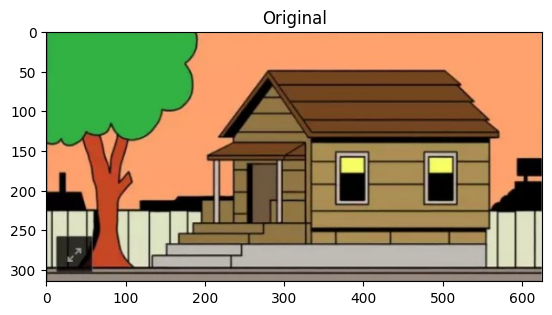

In [49]:
# 1. Khai báo thư viện ảnh
import numpy as np
import cv2
import matplotlib.pyplot as NguyenVanTungDuong

# Kiểm tra opencv đọc ảnh và đặt ảnh cho đúng hiển thị ban đầu
img = cv2.imread('hinh1.jpg')
if img is not None:
    NguyenVanTungDuong.imshow(img[:,:,::-1])
    NguyenVanTungDuong.title('Original')
    NguyenVanTungDuong.show()
else:
    print("Không tìm thấy ảnh hinh1.jpg.")


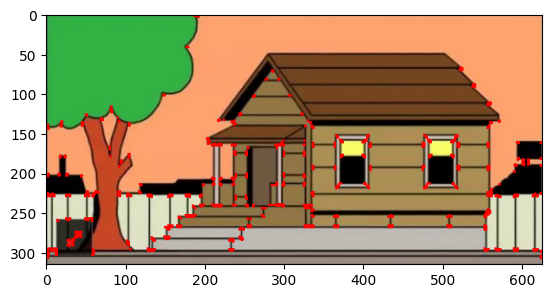

In [50]:
# 2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh
img = cv2.imread('hinh1.jpg')
if img is not None:
    gr = np.float32(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
    dst = cv2.cornerHarris(gr, 2, 3, 0.04)
    img[cv2.dilate(dst, None) > 0.01 * dst.max()] = [0, 0, 255]
    NguyenVanTungDuong.imshow(img[:,:,::-1])
    NguyenVanTungDuong.show()


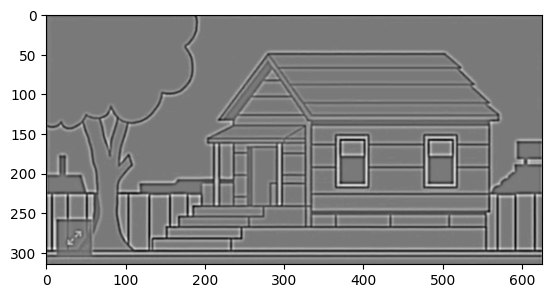

In [51]:
# 3. Sử dụng Band-pass filtering by Difference of Gaussians
img = cv2.imread('hinh1.jpg', 0)
if img is not None:
    blur1 = cv2.GaussianBlur(img, (5, 5), 1.0)
    blur2 = cv2.GaussianBlur(img, (9, 9), 2.0)
    dog = blur1.astype(np.float32) - blur2.astype(np.float32)
    NguyenVanTungDuong.imshow(np.uint8(cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX)), cmap='gray')
    NguyenVanTungDuong.show()


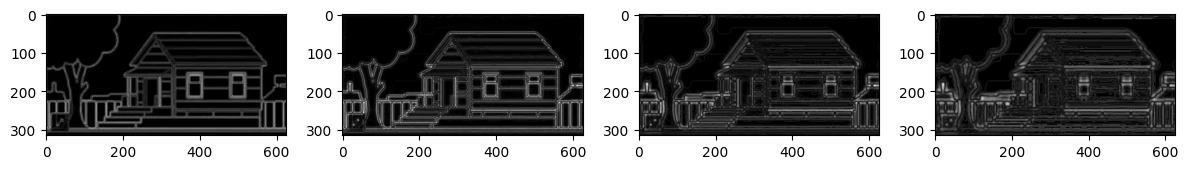

In [52]:
# 4. Kiểm tra ảnh qua Automatic Scale Selection
img = cv2.imread('hinh1.jpg', 0)
if img is not None:
    NguyenVanTungDuong.figure(figsize=(12, 3))
    for i, s in enumerate([1, 2, 3, 4]):
        ks = int(2*np.ceil(3*s)+1) | 1
        lg = cv2.Laplacian(cv2.GaussianBlur(img, (ks, ks), s), cv2.CV_64F, ksize=3)
        NguyenVanTungDuong.subplot(1, 4, i+1)
        NguyenVanTungDuong.imshow(np.uint8(cv2.normalize(np.abs(lg), None, 0, 255, cv2.NORM_MINMAX)), cmap='gray')
    NguyenVanTungDuong.tight_layout()
    NguyenVanTungDuong.show()


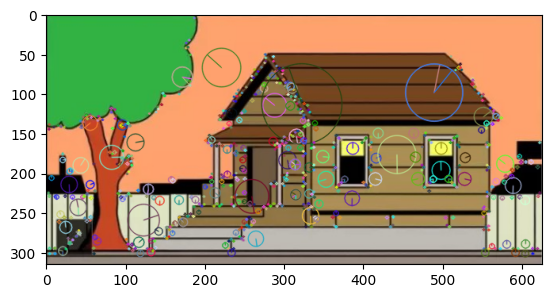

In [53]:
# 5. Kiểm tra ảnh qua Scale Invariant Detection
img = cv2.imread('hinh1.jpg')
if img is not None:
    sift = cv2.SIFT_create()
    kp = sift.detect(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), None)
    NguyenVanTungDuong.imshow(cv2.drawKeypoints(img, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)[:,:,::-1])
    NguyenVanTungDuong.show()


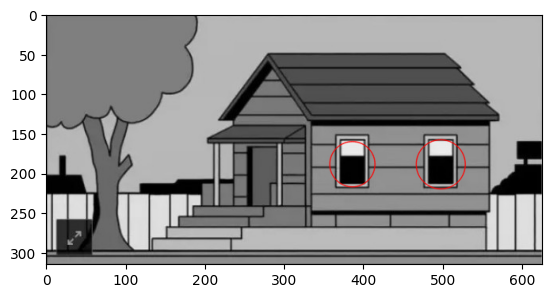

In [54]:
# 6. Kiểm tra ảnh qua Scale-space blob detector
img = cv2.imread('hinh1.jpg', 0)
if img is not None:
    p = cv2.SimpleBlobDetector_Params()
    p.filterByArea, p.minArea = True, 100
    kp = cv2.SimpleBlobDetector_create(p).detect(img)
    NguyenVanTungDuong.imshow(cv2.drawKeypoints(img, kp, np.array([]), (0,0,255), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)[:,:,::-1])
    NguyenVanTungDuong.show()


In [55]:
# 7. Thực hành với Bag-of-words detection
img1 = cv2.imread('hinh1.jpg', 0)
img2 = cv2.imread('hinh2.jpg', 0)
if img1 is not None and img2 is not None:
    sift = cv2.SIFT_create()
    _, d1 = sift.detectAndCompute(img1, None)
    _, d2 = sift.detectAndCompute(img2, None)
    trainer = cv2.BOWKMeansTrainer(10)
    if d1 is not None and d2 is not None:
        trainer.add(d1); trainer.add(d2)
        vocab = trainer.cluster()
        print("BoW dict shape:", vocab.shape)


BoW dict shape: (10, 128)


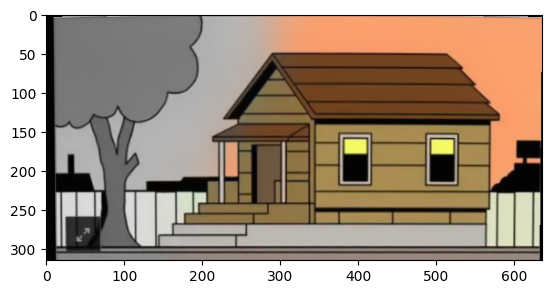

In [56]:
# 8. Ghép ảnh Image Panoramas
i1 = cv2.imread('hinh1.jpg')
i2 = cv2.imread('hinh2.jpg')
if i1 is not None and i2 is not None:
    status, pano = cv2.Stitcher_create().stitch([i1, i2])
    if status == 0:
        NguyenVanTungDuong.imshow(pano[:,:,::-1])
        NguyenVanTungDuong.show()
    else:
        print("Lỗi ghép pano", status)


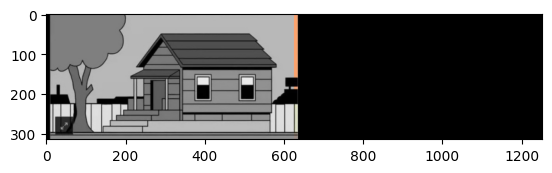

In [57]:
# 9. Ghép ảnh Automatic mosaicing
i1, i2 = cv2.imread('hinh1.jpg'), cv2.imread('hinh2.jpg')
if i1 is not None and i2 is not None:
    sift = cv2.SIFT_create()
    k1, d1 = sift.detectAndCompute(cv2.cvtColor(i1, cv2.COLOR_BGR2GRAY), None)
    k2, d2 = sift.detectAndCompute(cv2.cvtColor(i2, cv2.COLOR_BGR2GRAY), None)
    gd = [m for m, n in cv2.BFMatcher().knnMatch(d1, d2, k=2) if m.distance < 0.75 * n.distance]
    if len(gd) > 10:
        H, _ = cv2.findHomography(np.float32([k1[m.queryIdx].pt for m in gd]), np.float32([k2[m.trainIdx].pt for m in gd]), cv2.RANSAC, 5.0)
        res = cv2.warpPerspective(i1, H, (i1.shape[1] + i2.shape[1], i1.shape[0]))
        res[0:i2.shape[0], 0:i2.shape[1]] = i2
        NguyenVanTungDuong.imshow(res[:,:,::-1])
        NguyenVanTungDuong.show()
    else:
        print("Không đủ keypoint")


Fundamental Matrix được tính toán thành công:
 [[ 2.13072567e-09  6.38449459e-04 -9.97974306e-02]
 [-6.38411009e-04 -6.34714345e-08  2.48348114e-01]
 [ 9.97869868e-02 -2.54726729e-01  1.00000000e+00]]


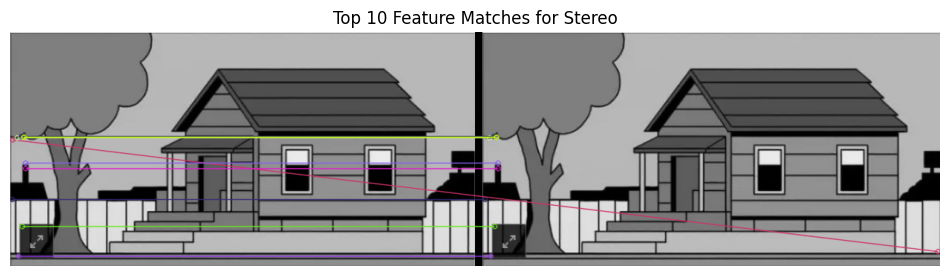

In [58]:
# 10. Sử dụng Wide base-line stereo
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc hai ảnh hinh1.jpg và hinh2.jpg (hoặc hinh2_shifted.jpg nếu có)
i1 = cv2.imread('hinh1.jpg', 0)
i2 = cv2.imread('hinh2.jpg', 0)

if i1 is not None and i2 is not None:
    # Kiểm tra xem 2 ảnh có giống hệt nhau không
    if np.array_equal(i1, i2):
        print("Cảnh báo: Hai ảnh đầu vào giống hệt nhau. Đang tự động tạo baseline giả lập...")
        rows, cols = i1.shape
        # Tạo độ lệch 15 pixel để có baseline cho Fundamental Matrix
        M = np.float32([[1, 0, 15], [0, 1, 0]])
        i2 = cv2.warpAffine(i1, M, (cols, rows))
    
    sift = cv2.SIFT_create()
    k1, d1 = sift.detectAndCompute(i1, None)
    k2, d2 = sift.detectAndCompute(i2, None)
    
    if d1 is not None and d2 is not None and len(d1) >= 2 and len(d2) >= 2:
        # Match features
        bf = cv2.BFMatcher()
        matches = bf.knnMatch(d1, d2, k=2)
        
        # Ratio test theo Lowe
        gd = [m for m, n in matches if m.distance < 0.8 * n.distance]
        
        # Chuyển đổi sang float32 để tránh lỗi findFundamentalMat
        p1 = np.float32([k1[m.queryIdx].pt for m in gd])
        p2 = np.float32([k2[m.trainIdx].pt for m in gd])
        
        if len(p1) >= 8:
            try:
                F, mask = cv2.findFundamentalMat(p1, p2, cv2.FM_LMEDS)
                if F is not None:
                    print("Fundamental Matrix được tính toán thành công:\n", F)
                    
                    # Vẽ điểm khớp tiêu biểu
                    img_matches = cv2.drawMatches(i1, k1, i2, k2, gd[:10], None, flags=2)
                    plt.figure(figsize=(12, 6))
                    plt.imshow(img_matches)
                    plt.title("Top 10 Feature Matches for Stereo")
                    plt.axis('off')
                    plt.show()
                else:
                    print("Lỗi: Không thể tính toán Fundamental Matrix.")
            except cv2.error as e:
                print(f"Lỗi OpenCV: {e}")
        else:
            print(f"Không đủ điểm khớp (Hiện có: {len(p1)}), cần ít nhất 8 điểm.")
else:
    print("Lỗi: Không tìm thấy ảnh đầu vào.")

In [59]:
# 11. CBIR
q, db = cv2.imread('hinh1.jpg'), cv2.imread('hinh2.jpg')
if q is not None and db is not None:
    c = lambda img: cv2.normalize(cv2.calcHist([cv2.cvtColor(img, cv2.COLOR_BGR2HSV)], [0,1], None, [50,60], [0,180,0,256]), None, 0, 1, cv2.NORM_MINMAX)
    print("Similarity:", cv2.compareHist(c(q), c(db), cv2.HISTCMP_CORREL))


Similarity: 0.04028771562410254


In [60]:
# 12. Bag-of-word with SIFT + Histogram
img = cv2.imread('hinh1.jpg', 0)
if img is not None:
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(img, None)
    if des is not None:
        tr = cv2.BOWKMeansTrainer(10)
        tr.add(des)
        bow = cv2.BOWImgDescriptorExtractor(sift, cv2.FlannBasedMatcher({'algorithm':1, 'trees':5}, {}))
        bow.setVocabulary(tr.cluster())
        print("Descriptor:\n", bow.compute(img, kp))


Descriptor:
 [[0.11688311 0.09090909 0.16233766 0.0948052  0.06753246 0.08831169
  0.12077922 0.06103896 0.1        0.09740259]]
